# Otimização de Rotas Médicas  - Entrega medicamentos

## Tech Challenge Fase 2

### Eduardo Toshio Yonamine - Grupo 37 - 14/07/2026

Sistema de otimização de rotas de entrega de médicamentos que usa algoritmos genéticos para resolver um VRP/TSP realista (múltiplos veículos, capacidade, autonomia, prioridades) e integra uma LLM para gerar relatórios operacionais e instruções para motoristas, operador e gerente.

----

# Instalação de pacotes necessários

In [1]:
!pip install numpy matplotlib groq --quiet
import pandas as pd
from typing import List,Optional, Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import copy
from dataclasses import dataclass


----

## Configurações de parâmetros globais

**Gerais**

1.   Penalidades
2.   Quantidade, número, capacidade e autonomia dos veículos
3.   Probabilidades mutação e crossover
4.   Paciencia de espera de melhoria nas gerações
5.   Tamanho da população (rotas a gerar)
6.   Verbose quando indicado imprime cada melhoria

**Two Opt**

1.   Limite máximo de iterações para evitar loop infinito


**Heuristica Construtiva: Vizinho mais próximo(Nearest Neighbor) para TSP**

1.   Número de soluções
2.   Item da lista

In [2]:
# ---------------------------------------------------------------------------
# Gerais
# ---------------------------------------------------------------------------
FATOR_PENALIDADE_PRIORIDADE = 5.0    # peso da penalidade de prioridade no custo
FATOR_PENALIDADE_CAPACIDADE = 17.0  # penalidade por unidade de carga acima da capacidade
FATOR_PENALIDADE_AUTONOMIA  = 1.0    # penalidade por pixel percorrido além da autonomia
 
PACIENCIA_ESPERA = 150 # gerações sem melhoria antes de repopular

TAMANHO_POPULACAO = 100

NUMERO_VEICULOS: 3
CAPACIDADE_VEICULO: 10.0
AUTONOMIA_VEICULO: 100.0
PROBABILIDADE_MUTACAO: float = 0.5
PROBABILIDADE_CROSSOVER: float = 1.0

VERBOSE = False


# Nearest Neighbor
NUMERO_SOLUCOES = 1


--------

# Hospital e lista de pontos de entrega

In [3]:
@dataclass
class PontoEntrega:
    """Representa um ponto de entrega de medicamentos ou insumos."""
    nome: str
    coords: tuple          # (x, y) em pixels ou coordenadas normalizadas
    prioridade: int        # 1=Alta, 2=Média, 3=Baixa
    tempo_atendimento: int # minutos estimados no local
    peso: float = 1.0      # carga a entregar (unidades/kg); usada para restrição de capacidade
    is_origin: bool = False

    def __hash__(self):
        return hash((self.nome, self.coords))

    def __eq__(self, other):
        if isinstance(other, PontoEntrega):
            return self.coords == other.coords
        return False

# ---------------------------------------------------------------------------
# Dataset de exemplo: Hospital Base + 14 pontos de entrega
# ---------------------------------------------------------------------------
PONTOS_ENTREGA: List[PontoEntrega] = [
    PontoEntrega("Hospital Base",            coords=(512, 317), prioridade=0, tempo_atendimento=0,  peso=0.0, is_origin=True),
    PontoEntrega("UBS Vila Nova",            coords=(741,  72), prioridade=1, tempo_atendimento=15, peso=2.0),
    PontoEntrega("Clínica São Lucas",        coords=(552,  50), prioridade=2, tempo_atendimento=10, peso=1.5),
    PontoEntrega("Posto Saúde Centro",       coords=(772, 346), prioridade=1, tempo_atendimento=20, peso=3.0),
    PontoEntrega("Paciente - Rua das Flores",(637,  12),        prioridade=1, tempo_atendimento=10, peso=1.0),
    PontoEntrega("Farmácia Popular Norte",   coords=(589, 131), prioridade=3, tempo_atendimento=5,  peso=4.0),
    PontoEntrega("UBS Jardim América",       coords=(732, 165), prioridade=2, tempo_atendimento=15, peso=2.0),
    PontoEntrega("Paciente - Av. Brasil",    coords=(605,  15), prioridade=1, tempo_atendimento=10, peso=1.0),
    PontoEntrega("Clínica Bem Estar",        coords=(730,  38), prioridade=2, tempo_atendimento=10, peso=1.5),
    PontoEntrega("Posto Saúde Sul",          coords=(576, 216), prioridade=2, tempo_atendimento=20, peso=2.5),
    PontoEntrega("UBS Parque Verde",         coords=(589, 381), prioridade=3, tempo_atendimento=15, peso=3.0),
    PontoEntrega("Farmácia Central",         coords=(711, 387), prioridade=3, tempo_atendimento=5,  peso=4.0),
    PontoEntrega("Paciente - Rua do Lago",   coords=(563, 228), prioridade=1, tempo_atendimento=10, peso=1.0),
    PontoEntrega("Posto Saúde Leste",        coords=(494,  22), prioridade=2, tempo_atendimento=20, peso=2.0),
    PontoEntrega("UBS Vila Esperança",       coords=(787, 288), prioridade=3, tempo_atendimento=15, peso=3.0),
]

def get_hospital_base() -> PontoEntrega:
    """Retorna o ponto de origem (hospital base)."""
    return next(p for p in PONTOS_ENTREGA if p.is_origin)


def get_pontos_entrega_sem_origem() -> List[PontoEntrega]:
    """Retorna apenas os pontos de entrega, excluindo o hospital base."""
    return [p for p in PONTOS_ENTREGA if not p.is_origin]


# Mapeamento reutilizável de prioridade para rótulo textual
PRIORIDADE_LABEL = {1: "Alta", 2: "Média", 3: "Baixa"}



***Executando as rotinas***

In [4]:

print("Origem e retorno:", PONTOS_ENTREGA[0].nome)
print("Total de pontos de entrega:", len(PONTOS_ENTREGA))
i = 0
for p in PONTOS_ENTREGA:
    i = i + 1
    print(f"{i} - {p.nome} | coords={p.coords} | prioridade={p.prioridade} | peso={p.peso}")

Origem e retorno: Hospital Base
Total de pontos de entrega: 15
1 - Hospital Base | coords=(512, 317) | prioridade=0 | peso=0.0
2 - UBS Vila Nova | coords=(741, 72) | prioridade=1 | peso=2.0
3 - Clínica São Lucas | coords=(552, 50) | prioridade=2 | peso=1.5
4 - Posto Saúde Centro | coords=(772, 346) | prioridade=1 | peso=3.0
5 - Paciente - Rua das Flores | coords=(637, 12) | prioridade=1 | peso=1.0
6 - Farmácia Popular Norte | coords=(589, 131) | prioridade=3 | peso=4.0
7 - UBS Jardim América | coords=(732, 165) | prioridade=2 | peso=2.0
8 - Paciente - Av. Brasil | coords=(605, 15) | prioridade=1 | peso=1.0
9 - Clínica Bem Estar | coords=(730, 38) | prioridade=2 | peso=1.5
10 - Posto Saúde Sul | coords=(576, 216) | prioridade=2 | peso=2.5
11 - UBS Parque Verde | coords=(589, 381) | prioridade=3 | peso=3.0
12 - Farmácia Central | coords=(711, 387) | prioridade=3 | peso=4.0
13 - Paciente - Rua do Lago | coords=(563, 228) | prioridade=1 | peso=1.0
14 - Posto Saúde Leste | coords=(494, 22) 

---

# Representação Genética

## (giant tour) + exemplo de cromossomo


In [5]:
# Célula 3: Representação genética (giant tour)
# Roteiro: "Explico que o cromossomo é uma permutação de todos os pontos (sem depósito)."

# Exemplo de cromossomo (IDs ou nomes na ordem de visita)
pontos = get_pontos_entrega_sem_origem()
cromossomo_exemplo = [p.nome for p in pontos]  # ordem natural
# Para demonstrar, embaralhamos uma permutação exemplo
random.shuffle(cromossomo_exemplo)

print("Cromossomo (giant tour) exemplo:")
print(cromossomo_exemplo)


Cromossomo (giant tour) exemplo:
['Paciente - Rua do Lago', 'Clínica São Lucas', 'UBS Vila Esperança', 'Farmácia Central', 'UBS Parque Verde', 'UBS Vila Nova', 'Posto Saúde Sul', 'Clínica Bem Estar', 'Farmácia Popular Norte', 'Paciente - Av. Brasil', 'UBS Jardim América', 'Posto Saúde Centro', 'Posto Saúde Leste', 'Paciente - Rua das Flores']


# Operadores Genéticos 


<style>
  .titulo {
    font-size: 20px;
    font-weight: bold;
    padding: 10px;
    border-radius: 6px;
    margin-top: 25px;
    margin-bottom: 10px;
  }
  .crossover {
    background-color: #e3f2fd;
    border-left: 6px solid #2196f3;
  }
  .mutacao {
    background-color: #e8f5e9;
    border-left: 6px solid #4caf50;
  }
  .codigo {
    font-family: monospace;
    background-color: #f1f3f4;
    padding: 10px;
    border-radius: 6px;
    white-space: pre-wrap;
  }
</style>

---

## 🔵 **PMX — Partially Mapped Crossover**
<p>Preserva um segmento de um pai e usa mapeamento para preencher o restante sem duplicar pontos.</p>
<div class="codigo">
    
**Pai1:**

['UBS Vila Nova', 'Clínica São Lucas',<br>
'Farmácia Popular Norte', 'Posto Saúde Sul', 'Farmácia Central', 'UBS Vila Esperança']<br><br>
<b>Pai2:</b><br>
['Paciente - Rua do Lago', 'UBS Jardim América',<br>
'Farmácia Central', 'Posto Saúde Sul', 'Farmácia Popular Norte', 'Clínica Bem Estar']<br><br>
<b>Filho:</b><br>
['Paciente - Rua do Lago', 'UBS Jardim América',<br>
'Farmácia Popular Norte', 'Posto Saúde Sul', 'Farmácia Central', 'Clínica Bem Estar']
</div>

---

## 🔵 **OX — Order Crossover**

<p>Copia um trecho contínuo de um pai e completa com a ordem relativa do outro pai.</p>
<div class="codigo">
<b>Pai1:</b><br>
['UBS Vila Nova', 'Clínica São Lucas',<br>
'Farmácia Popular Norte', 'Posto Saúde Sul', 'Farmácia Central']<br><br>
<b>Pai2:</b><br>
['Posto Saúde Centro', 'Paciente - Av. Brasil',<br>
'Paciente - Rua das Flores', 'UBS Parque Verde', 'Posto Saúde Leste']<br><br>
<b>Filho:</b><br>
['Posto Saúde Centro', 'Paciente - Av. Brasil',<br>
'Farmácia Popular Norte', 'Posto Saúde Sul', 'UBS Parque Verde', 'Posto Saúde Leste']
</div>


---

## 🟢 **Mutação por Troca de Adjacentes**

<p>Troca dois pontos consecutivos da rota com certa probabilidade.</p>
<div class="codigo">
<b>Antes:</b><br>
['UBS Vila Nova', 'Clínica São Lucas', 'Farmácia Popular Norte', 'Posto Saúde Sul']<br><br>
<b>Depois:</b><br>
['UBS Vila Nova', 'Farmácia Popular Norte', 'Clínica São Lucas', 'Posto Saúde Sul']
</div>

---

## 🟢 **Mutação por Inversão de Segmento**

<p>Seleciona dois índices aleatórios e inverte o trecho entre eles.</p>
<div class="codigo">
<b>Antes:</b><br>
['UBS Vila Nova', 'Clínica São Lucas', 'Farmácia Popular Norte', 'Posto Saúde Sul', 'Farmácia Central']<br><br>
<b>Depois:</b><br>
['UBS Vila Nova', 'Clínica São Lucas', 'Farmácia Central', 'Posto Saúde Sul', 'Farmácia Popular Norte']
</div>


In [6]:
# ---------------------------------------------------------------------------
# Operadores genéticos
# ---------------------------------------------------------------------------

def pmx_crossover(parent1: List[PontoEntrega], parent2: List[PontoEntrega]) -> List[PontoEntrega]:
    """
    Partially Mapped Crossover (PMX) para permutações.
    Garante filhos válidos sem duplicação de genes.
    """
    length = len(parent1)
    start, end = sorted(random.sample(range(length), 2))
    child = [None] * length

    # Copia segmento do primeiro pai
    child[start:end+1] = parent1[start:end+1]

    # Mapeamento
    for i in range(start, end+1):
        if parent2[i] not in child:
            pos = i
            while child[pos] is not None:
                pos = parent2.index(parent1[pos])
            child[pos] = parent2[i]

    # Preenche posições restantes
    for i in range(length):
        if child[i] is None:
            child[i] = parent2[i]

    return child

def order_crossover(
    parent1: List[PontoEntrega],
    parent2: List[PontoEntrega]
) -> List[PontoEntrega]:
    """
    Operador de crossover por ordem (OX — Order Crossover) para permutações.

    Preserva a estrutura de permutação válida, evitando duplicidade de cidades.

    Parâmetros:
    - parent1: rota do primeiro pai
    - parent2: rota do segundo pai

    Retorno:
    - rota filho resultante da recombinação
    """
    length = len(parent1)
    start_index = random.randint(0, length - 1)
    end_index = random.randint(start_index + 1, length)

    child = parent1[start_index:end_index]
    remaining_positions = [i for i in range(length) if i < start_index or i >= end_index]
    remaining_genes = [gene for gene in parent2 if gene not in child]

    for position, gene in zip(remaining_positions, remaining_genes):
        child.insert(position, gene)

    return child

def mutate(
    rota: List[PontoEntrega],
    probabilidade_mutacao: float
) -> List[PontoEntrega]:
    """
    Operador de mutação: troca dois pontos adjacentes da rota com dada probabilidade.

    Preserva a validade da permutação.

    Parâmetros:
    - rota: sequência de pontos de entrega
    - probabilidade_mutacao: probabilidade de ocorrer mutação [0.0, 1.0]

    Retorno:
    - rota mutada (ou cópia da original se mutação não ocorrer)
    """
    rota_mutada = copy.deepcopy(rota)

    if random.random() < probabilidade_mutacao:
        if len(rota) < 2:
            return rota_mutada
        index = random.randint(0, len(rota) - 2)
        rota_mutada[index], rota_mutada[index + 1] = rota[index + 1], rota[index]

    return rota_mutada

def mutate_segment_inversion(
    rota: List[PontoEntrega],
    probabilidade_mutacao: float
) -> List[PontoEntrega]:
    """
    Operador de mutação por inversão de segmento:
    escolhe dois índices aleatórios e inverte o trecho entre eles.

    Parâmetros:
    - rota: sequência de pontos de entrega
    - probabilidade_mutacao: probabilidade de ocorrer mutação [0.0, 1.0]

    Retorno:
    - rota mutada (ou cópia da original se mutação não ocorrer)
    """
    rota_mutada = copy.deepcopy(rota)

    if random.random() < probabilidade_mutacao and len(rota) > 2:
        i, j = sorted(random.sample(range(len(rota)), 2))
        rota_mutada[i:j+1] = reversed(rota_mutada[i:j+1])

    return rota_mutada

## Gráfico explicativo dos operadores genéticos




<div style="text-align:center">
    <img src="imagens/operadores_geneticos.png" alt="Infográfico do fluxo de fitness" width="400">    
</div>

----

## 🧩 Funções de Fitness no Projeto VRP/TSP

O projeto utiliza duas funções de *fitness* para avaliar a qualidade das soluções geradas no problema de **roteamento de veículos (VRP)** e **caixeiro viajante (TSP)** aplicadas à entrega de medicamentos.

Essas funções medem o **custo total** de cada rota considerando:
- **Distância percorrida** (eficiência logística)
- **Penalidades** por violação de restrições operacionais:
  - Prioridade de pacientes
  - Capacidade de carga do veículo
  - Autonomia máxima de deslocamento

O objetivo do *fitness* é **minimizar o custo total**, favorecendo rotas curtas e viáveis que respeitem as restrições impostas.

As duas funções principais são:
1. `calcular_custo_rota` → avalia uma rota individual.
2. `calcular_custo_giant_tour_vrp` → avalia um conjunto de rotas (giant tour) para múltiplos veículos.

A seguir, cada função é detalhada com seus componentes e lógica de cálculo.


#### Função `calcular_custo_rota`

Avalia o custo de uma rota individual, incluindo o retorno ao hospital base.

**Componentes do custo:**
- **Distância total:** soma das distâncias entre todos os pontos da rota + retorno ao depósito.
- **Penalidade de prioridade:** pacientes críticos (prioridade 1 ou 2) atendidos mais tarde recebem penalidade proporcional à posição na rota.
- **Penalidade de capacidade:** aplicada quando o peso total excede a capacidade do veículo.
- **Penalidade de autonomia:** aplicada quando a distância total excede a autonomia do veículo.

**Fórmula geral:**
Custo total = Distância + Penalidade_prioridade + Penalidade_capacidade + Penalidade_autonomia


In [7]:
# ---------------------------------------------------------------------------
# Função de custo (fitness)
# ---------------------------------------------------------------------------

def calcular_custo_rota(
    rota: List[PontoEntrega],
    hospital_base: PontoEntrega,
    fator_penalidade: float = FATOR_PENALIDADE_PRIORIDADE,
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    fator_penalidade_capacidade: float = FATOR_PENALIDADE_CAPACIDADE,
    fator_penalidade_autonomia: float = FATOR_PENALIDADE_AUTONOMIA,
) -> float:
    """
    Calcula o custo total de uma rota incluindo distância e penalidades de restrições.

    Penalidades aplicadas:
    - Prioridade   : pacientes críticos atendidos tarde recebem penalidade proporcional
                     à (posição / prioridade) × fator_penalidade.
    - Capacidade   : excesso de carga além de ``capacidade_veiculo`` é penalizado de forma
                     proporcional ao excesso relativo (excesso/capacidade × fator).
    - Autonomia    : excesso de distância além de ``autonomia_veiculo`` é penalizado por
                     (excesso_pixels × fator_penalidade_autonomia).
    """
    rota_completa = [hospital_base] + list(rota) + [hospital_base]
    n = len(rota_completa)

    # Distância total do ciclo
    distancia_total = sum(
        calcular_distancia(rota_completa[i], rota_completa[i + 1])
        for i in range(n - 1)
    )

    # Penalidade por prioridade
    penalidade_prioridade = 0.0
    for posicao, ponto in enumerate(rota, start=1):
        if ponto.prioridade in (1, 2):
            penalidade_prioridade += (posicao / ponto.prioridade) * fator_penalidade

    # Penalidade proporcional por capacidade
    penalidade_capacidade = 0.0
    if capacidade_veiculo is not None:
        peso_total = sum(p.peso for p in rota)
        excesso = max(0.0, peso_total - capacidade_veiculo)
        if excesso > 0:
            excesso_relativo = excesso / capacidade_veiculo
            penalidade_capacidade = excesso_relativo * fator_penalidade_capacidade

    # Penalidade por autonomia
    penalidade_autonomia = 0.0
    if autonomia_veiculo is not None:
        excesso = max(0.0, distancia_total - autonomia_veiculo)
        penalidade_autonomia = excesso * fator_penalidade_autonomia

    return distancia_total + penalidade_prioridade + penalidade_capacidade + penalidade_autonomia



***Função `calcular_custo_giant_tour_vrp***

Avalia um *giant tour* (sequência única de pontos) e divide em sub-rotas para múltiplos veículos.

**Etapas principais:**
1. Percorre os pontos do *giant tour* acumulando peso e distância.
2. Se exceder capacidade ou autonomia, fecha a rota atual e inicia uma nova (se houver veículos disponíveis).
3. Calcula o custo de cada sub-rota usando `calcular_custo_rota`.
4. Soma todos os custos para obter o custo total do *giant tour*.

**Resultado final:**
Fitness total = Σ (custos das sub-rotas)


In [8]:
def calcular_custo_giant_tour_vrp(
    giant_tour: List[PontoEntrega],
    hospital_base: PontoEntrega,
    n_veiculos: int,
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    fator_penalidade: float = FATOR_PENALIDADE_PRIORIDADE,
    fator_penalidade_capacidade: float = FATOR_PENALIDADE_CAPACIDADE,
    fator_penalidade_autonomia: float = FATOR_PENALIDADE_AUTONOMIA,
) -> float:
    rotas: List[List[PontoEntrega]] = []
    rota_atual: List[PontoEntrega] = []
    peso_atual: float = 0.0
    dist_atual: float = 0.0
    ponto_anterior: PontoEntrega = hospital_base

    for ponto in giant_tour:
        dist_passo = calcular_distancia(ponto_anterior, ponto)
        dist_retorno = calcular_distancia(ponto, hospital_base)

        capacidade_violada = (
            capacidade_veiculo is not None
            and peso_atual + ponto.peso > capacidade_veiculo
        )
        autonomia_violada = (
            autonomia_veiculo is not None
            and dist_atual + dist_passo + dist_retorno > autonomia_veiculo
        )

        veiculos_disponiveis = len(rotas) < n_veiculos - 1
        if (capacidade_violada or autonomia_violada) and rota_atual and veiculos_disponiveis:
            rotas.append(rota_atual)
            rota_atual = []
            peso_atual = 0.0
            dist_atual = 0.0
            ponto_anterior = hospital_base
            dist_passo = calcular_distancia(hospital_base, ponto)

        rota_atual.append(ponto)
        peso_atual += ponto.peso
        dist_atual += dist_passo
        ponto_anterior = ponto

    if rota_atual:
        rotas.append(rota_atual)

    # Soma dos custos de cada sub-rota
    custo_total = 0.0
    for rota in rotas:
        custo_total += calcular_custo_rota(
            rota, hospital_base,
            fator_penalidade=fator_penalidade,
            capacidade_veiculo=capacidade_veiculo,
            autonomia_veiculo=autonomia_veiculo,
            fator_penalidade_capacidade=fator_penalidade_capacidade,
            fator_penalidade_autonomia=fator_penalidade_autonomia,
        )
    return custo_total


***Fluxograma visual simplificado***
<div style="text-align:center">
    <img src="imagens/fitness.png" alt="Infográfico do fluxo de fitness" width="400">    
</div>


## 🚚 VRP Split e 🔧 Refinamento Local (Two‑Opt)

- O *giant tour* é uma sequência única de todos os pontos de entrega.
- O algoritmo **Split** divide esse tour em **sub‑rotas**, cada uma atribuída a um veículo.
- A divisão respeita **capacidade de carga** e **autonomia máxima** do veículo.
- Cada sub‑rota começa e termina no depósito (hospital).

**Exemplo:**
- Giant tour: `[Depósito, A, B, C, D, E, Depósito]`
- Split →  
  - Veículo 1: `[Depósito, A, B, Depósito]`  
  - Veículo 2: `[Depósito, C, D, E, Depósito]`

---

***Refinamento Local (Two‑Opt)***

- Objetivo: **reduzir a distância total** da rota trocando pares de arestas.
- Como funciona: remove duas conexões e reconecta os pontos em ordem diferente.
- Se a nova rota for mais curta, a mudança é aceita.
- Aplica‑se o Two‑Opt em cada sub‑rota obtida no Split.

**Antes (rota não refinada):**
Depósito → A → B → C → D → Depósito
Distância total = 120 km


**Depois (aplicando Two‑Opt, troca entre B e D):**
Depósito → A → D → C → B → Depósito
Distância total = 105 km


---

### Observações
- O **Split** garante rotas viáveis por veículo.
- O **Two‑Opt** melhora cada rota sem alterar os pontos visitados, apenas a ordem.
- Assim, obtemos soluções mais eficientes para o problema de rotas de entrega médica.



In [9]:
# Célula: VRP Split final (dividir_rotas_vrp + calcular_custo_vrp + resumo_restricoes_vrp)
# Roteiro curto: "Decodificamos o giant tour em sub-rotas, avaliamos custo e checamos restrições."

def calcular_distancia(a: "PontoEntrega", b: "PontoEntrega") -> float:
    """Distância Euclidiana entre dois pontos (usa coords=(x,y))."""
    (ax, ay), (bx, by) = a.coords, b.coords
    return ((ax - bx) ** 2 + (ay - by) ** 2) ** 0.5

def calcular_custo_rota(
    rota: List["PontoEntrega"],
    hospital_base: "PontoEntrega",
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    penalidade_cap: float = FATOR_PENALIDADE_CAPACIDADE,
    penalidade_auto: float = FATOR_PENALIDADE_AUTONOMIA,
) -> float:
    """
    Custo de uma rota: soma das distâncias (ida+volta) + penalidades por violação.
    Penalidades são altas para tornar soluções inviáveis menos atrativas ao GA.
    """
    if not rota:
        return 0.0
    rota_completa = [hospital_base] + rota + [hospital_base]
    distancia = sum(calcular_distancia(rota_completa[i], rota_completa[i + 1])
                    for i in range(len(rota_completa) - 1))
    peso_total = sum(p.peso for p in rota)
    custo = distancia
    if capacidade_veiculo is not None and peso_total > capacidade_veiculo:
        custo += penalidade_cap + 10.0 * (peso_total - capacidade_veiculo)
    if autonomia_veiculo is not None and distancia > autonomia_veiculo:
        custo += penalidade_auto + 10.0 * (distancia - autonomia_veiculo)
    return custo

def dividir_rotas_vrp(
    giant_tour: List["PontoEntrega"],
    hospital_base: "PontoEntrega",
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    n_veiculos: Optional[int] = None,
    verbose: bool = False,
) -> Tuple[List[List["PontoEntrega"]], Dict]:
    """
    Divide um giant tour em sub-rotas válidas por veículo (greedy split).

    Retorna:
      - rotas: List[List[PontoEntrega]] (cada sub-rota não inclui o hospital)
      - meta: dict com metadados: n_veiculos_usados, n_rotas_infeasible, infeasible_indices
    """
    # Validações básicas
    if n_veiculos is not None and n_veiculos < 1:
        raise ValueError("n_veiculos deve ser >= 1 ou None.")
    # Filtra caso o giant_tour contenha o depósito por engano
    giant = [p for p in giant_tour if not getattr(p, "is_origin", False)]

    rotas: List[List["PontoEntrega"]] = []
    rota_atual: List["PontoEntrega"] = []
    peso_atual: float = 0.0
    dist_atual: float = 0.0
    ponto_anterior: "PontoEntrega" = hospital_base

    for idx, ponto in enumerate(giant, start=1):
        dist_passo = calcular_distancia(ponto_anterior, ponto)
        dist_retorno = calcular_distancia(ponto, hospital_base)

        capacidade_violada = (
            capacidade_veiculo is not None and (peso_atual + ponto.peso) > capacidade_veiculo
        )
        autonomia_violada = (
            autonomia_veiculo is not None and (dist_atual + dist_passo + dist_retorno) > autonomia_veiculo
        )

        veiculos_disponiveis = True
        if n_veiculos is not None:
            # permitimos abrir novas rotas enquanto já não tivermos fechado n_veiculos-1 rotas
            veiculos_disponiveis = len(rotas) < max(0, n_veiculos - 1)

        if verbose:
            print(f"[Passo {idx}] avaliando '{ponto.nome}': peso_atual={peso_atual:.1f}, dist_atual={dist_atual:.1f}")
            print(f"  dist_passo={dist_passo:.1f}, dist_retorno={dist_retorno:.1f}")
            if capacidade_violada:
                print("  -> violação de capacidade se adicionar este ponto.")
            if autonomia_violada:
                print("  -> violação de autonomia se adicionar este ponto.")

        # Se violaria e já há pontos na rota atual e ainda posso abrir novo veículo:
        if (capacidade_violada or autonomia_violada) and rota_atual and veiculos_disponiveis:
            if verbose:
                print("  >>> Abrindo nova rota (fechando rota atual).")
            rotas.append(rota_atual)
            rota_atual = []
            peso_atual = 0.0
            dist_atual = 0.0
            ponto_anterior = hospital_base
            # recalcula distância do depósito até este ponto
            dist_passo = calcular_distancia(hospital_base, ponto)
            if verbose:
                print(f"  >>> dist_passo recalculado desde depósito: {dist_passo:.1f}")

        rota_atual.append(ponto)
        peso_atual += ponto.peso
        dist_atual += dist_passo
        ponto_anterior = ponto

        if verbose:
            print(f"  -> ponto adicionado. rota atual tem {len(rota_atual)} pontos; peso_atual={peso_atual:.1f}, dist_atual={dist_atual:.1f}\n")

    if rota_atual:
        rotas.append(rota_atual)

    # Diagnóstico de infeasibilidades por rota (após construção)
    infeasible_indices = []
    for i, rota in enumerate(rotas):
        peso = sum(p.peso for p in rota)
        rota_completa = [hospital_base] + rota + [hospital_base]
        distancia = sum(calcular_distancia(rota_completa[j], rota_completa[j + 1]) for j in range(len(rota_completa) - 1))
        cap_ok = capacidade_veiculo is None or peso <= capacidade_veiculo
        auto_ok = autonomia_veiculo is None or distancia <= autonomia_veiculo
        if not (cap_ok and auto_ok):
            infeasible_indices.append(i)

    meta = {
        "n_veiculos_usados": len(rotas),
        "n_rotas_infeasible": len(infeasible_indices),
        "infeasible_indices": infeasible_indices,
    }

    if verbose:
        print(f"Split finalizado: veículos usados = {meta['n_veiculos_usados']}, rotas infeasible = {meta['n_rotas_infeasible']}")
    return rotas, meta

def calcular_custo_vrp(
    rotas_vrp: List[List["PontoEntrega"]],
    hospital_base: "PontoEntrega",
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    penalidade_cap: float = FATOR_PENALIDADE_CAPACIDADE,
    penalidade_auto: float = 10,
) -> Tuple[float, List[float]]:
    """
    Calcula custo total e custos por veículo usando calcular_custo_rota.
    """
    custos = [
        calcular_custo_rota(
            rota, hospital_base,
            capacidade_veiculo=capacidade_veiculo,
            autonomia_veiculo=autonomia_veiculo,
            penalidade_cap=penalidade_cap,
            penalidade_auto=penalidade_auto,
        )
        for rota in rotas_vrp
    ]
    return sum(custos), custos

def resumo_restricoes_vrp(
    rotas_vrp: List[List["PontoEntrega"]],
    hospital_base: "PontoEntrega",
    capacidade_veiculo: Optional[float],
    autonomia_veiculo: Optional[float],
) -> List[dict]:
    """
    Gera resumo diagnóstico por veículo: peso, distância, flags de capacidade/autonomia e lista de pontos.
    """
    resumo = []
    for idx, rota in enumerate(rotas_vrp, start=1):
        peso = sum(p.peso for p in rota)
        rota_completa = [hospital_base] + rota + [hospital_base]
        distancia = sum(
            calcular_distancia(rota_completa[i], rota_completa[i + 1])
            for i in range(len(rota_completa) - 1)
        )
        capacidade_ok = capacidade_veiculo is None or peso <= capacidade_veiculo
        autonomia_ok = autonomia_veiculo is None or distancia <= autonomia_veiculo

        resumo.append({
            "veiculo": idx,
            "n_pontos": len(rota),
            "peso_total": round(peso, 2),
            "capacidade_veiculo": capacidade_veiculo,
            "capacidade_ok": capacidade_ok,
            "distancia": round(distancia, 2),
            "autonomia_veiculo": autonomia_veiculo,
            "autonomia_ok": autonomia_ok,
            "pontos": [p.nome for p in rota],
        })
    return resumo



***Demonstração da execução - Divisão das rotas***


In [10]:

# -------------------------
# Demonstração rápida (execute durante o vídeo)
# -------------------------
# Observação: assume que get_hospital_base() e get_pontos_entrega_sem_origem() já existem
hospital = get_hospital_base()
pontos = get_pontos_entrega_sem_origem()

# Exemplo de cromossomo (giant tour) — ajuste a ordem para demonstrar diferentes splits
cromossomo_exemplo = [p.nome for p in pontos]  # ordem natural
# Para demo, embaralhe para mostrar comportamento (opcional)
import random
random.seed(42)
random.shuffle(cromossomo_exemplo)

# Mapeia nomes para objetos
mapa = {p.nome: p for p in pontos}
giant_tour = [mapa[n] for n in cromossomo_exemplo]

# Parâmetros de demo (reduza capacidade para forçar splits)
capacidade_veiculo = 8.0
autonomia_veiculo = 450.0
n_veiculos = 3

print("\n=== Executando dividir_rotas_vrp (versão final) ===\n")
rotas, meta = dividir_rotas_vrp(giant_tour, hospital, capacidade_veiculo, autonomia_veiculo, n_veiculos, verbose=True)

custo_total, custos_por_veiculo = calcular_custo_vrp(rotas, hospital, capacidade_veiculo, autonomia_veiculo)
resumo = resumo_restricoes_vrp(rotas, hospital, capacidade_veiculo, autonomia_veiculo)

print("\n=== Resultado do Split ===")
for i, rota in enumerate(rotas, start=1):
    nomes = [p.nome for p in rota]
    peso = sum(p.peso for p in rota)
    print(f"Veículo {i}: {nomes} | peso_total={peso:.1f}")

print(f"\nMeta: {meta}")
print(f"\nCusto total (com penalidades): {custo_total:.2f}")
print("Custos por veículo:", [round(c,2) for c in custos_por_veiculo])

print("\n=== Resumo de restrições por veículo ===")
for r in resumo:
    print(r)

# Observação final para o apresentador:
print("\nObservações:")
print("- O split é linear O(n) sobre o giant tour.")
print("- O último veículo pode ficar com rotas infeasible se n_veiculos limitar aberturas; meta['infeasible_indices'] indica quais.")
print("- Use 'verbose=True' para mostrar passo a passo durante a gravação.")


=== Executando dividir_rotas_vrp (versão final) ===

[Passo 1] avaliando 'Posto Saúde Sul': peso_atual=0.0, dist_atual=0.0
  dist_passo=119.6, dist_retorno=119.6
  -> ponto adicionado. rota atual tem 1 pontos; peso_atual=2.5, dist_atual=119.6

[Passo 2] avaliando 'Posto Saúde Leste': peso_atual=2.5, dist_atual=119.6
  dist_passo=210.6, dist_retorno=295.5
  -> violação de autonomia se adicionar este ponto.
  >>> Abrindo nova rota (fechando rota atual).
  >>> dist_passo recalculado desde depósito: 295.5
  -> ponto adicionado. rota atual tem 1 pontos; peso_atual=2.0, dist_atual=295.5

[Passo 3] avaliando 'Clínica Bem Estar': peso_atual=2.0, dist_atual=295.5
  dist_passo=236.5, dist_retorno=354.1
  -> violação de autonomia se adicionar este ponto.
  >>> Abrindo nova rota (fechando rota atual).
  >>> dist_passo recalculado desde depósito: 354.1
  -> ponto adicionado. rota atual tem 1 pontos; peso_atual=1.5, dist_atual=354.1

[Passo 4] avaliando 'Paciente - Av. Brasil': peso_atual=1.5, dist

## Heurística Construtiva: Vizinho Mais Próximo (Nearest Neighbor)

O algoritmo **Nearest Neighbor (NN)** é uma heurística clássica para o Problema do Caixeiro Viajante (TSP), utilizada aqui como etapa inicial na construção de soluções para o VRP de entregas médicas.

### Passos do algoritmo:
1. Inicia no hospital base (ponto de origem).
2. A cada passo, visita o ponto de entrega ainda não visitado mais próximo do atual.
3. Ao esgotar todos os pontos, retorna ao hospital base (ciclo fechado).

### Complexidade:
- O algoritmo possui complexidade **O(n²)**, já que a cada passo é necessário buscar o ponto mais próximo entre os não visitados.

### Uso no pipeline:
- Gera soluções iniciais de qualidade superior às puramente aleatórias.
- Inicializa parte da população do Algoritmo Genético (GA), acelerando a convergência.
- Serve como **baseline** de comparação com a solução final (GA + Two Opt).

---
## Funções do método Vizinho Mais Próximo (NN)

Nesta seção temos três funções relacionadas ao algoritmo **Nearest Neighbor (NN)**:

1. **`nearest_neighbor`**  
   - Implementa o algoritmo clássico do vizinho mais próximo.  
   - Constrói **uma rota única**, partindo do hospital base e sempre escolhendo o ponto mais próximo ainda não visitado.  
   - Retorna apenas a sequência de pontos.

2. **`gerar_populacao_nearest_neighbor`**  
   - Usa o mesmo algoritmo NN, mas permite gerar **múltiplas rotas**.  
   - Faz isso variando o ponto de partida interno (após sair do hospital).  
   - É útil para criar uma **população inicial de soluções NN**, por exemplo, em algoritmos evolutivos como o GA.

3. **`avaliar_baseline_nn`**  
   - Função de **avaliação**.  
   - Executa o NN padrão (hospital como origem) e calcula o **custo total da rota**.  
   - Retorna `(rota_nn, custo_nn)` e serve como **baseline de comparação** contra métodos mais sofisticados (como GA + Two Opt).

---

In [11]:

def nearest_neighbor(
    locais_entrega: List[PontoEntrega],
    hospital_base: PontoEntrega
) -> List[PontoEntrega]:
    """
    Constrói uma rota pelo método do Vizinho Mais Próximo.

    Parâmetros:
    - locais_entrega: pontos de entrega a visitar (sem o hospital base)
    - hospital_base: ponto de partida e retorno

    Retorno:
    - rota ordenada de pontos de entrega (sem o hospital base nos extremos)
    """
    nao_visitados = list(locais_entrega)
    rota: List[PontoEntrega] = []
    ponto_atual: PontoEntrega = hospital_base

    while nao_visitados:
        mais_proximo = min(nao_visitados,
                           key=lambda p: calcular_distancia(ponto_atual, p))
        rota.append(mais_proximo)
        nao_visitados.remove(mais_proximo)
        ponto_atual = mais_proximo

    return rota


def gerar_populacao_nearest_neighbor(
    locais_entrega: List[PontoEntrega],
    hospital_base: PontoEntrega,
    n_solucoes: int = 1
) -> List[List[PontoEntrega]]:
    """
    Gera múltiplas soluções via Nearest Neighbor com pontos de partida variados.

    Para n_solucoes > 1, utiliza pontos de entrega aleatórios como ponto de
    partida interno (após sair do hospital base), gerando variações do NN.

    Parâmetros:
    - locais_entrega: pontos de entrega (sem o hospital base)
    - hospital_base: ponto de origem e retorno
    - n_solucoes: número de soluções NN a gerar

    Retorno:
    - lista de rotas geradas pelo método NN
    """
    import random

    solucoes: List[List[PontoEntrega]] = []

    # Primeira solução: NN padrão iniciando do hospital base
    solucoes.append(nearest_neighbor(locais_entrega, hospital_base))

    # Demais soluções: NN iniciando de pontos de partida internos aleatórios
    for _ in range(n_solucoes - 1):
        ponto_partida = random.choice(locais_entrega)
        nao_visitados = [p for p in locais_entrega if p != ponto_partida]
        rota = [ponto_partida]
        ponto_atual = ponto_partida

        while nao_visitados:
            mais_proximo = min(nao_visitados,
                               key=lambda p: calcular_distancia(ponto_atual, p))
            rota.append(mais_proximo)
            nao_visitados.remove(mais_proximo)
            ponto_atual = mais_proximo

        solucoes.append(rota)

    return solucoes


def avaliar_baseline_nn(
    locais_entrega: List[PontoEntrega],
    hospital_base: PontoEntrega
) -> Tuple[List[PontoEntrega], float]:
    """
    Retorna a rota NN padrão e seu custo, para uso como baseline de comparação.

    Parâmetros:
    - locais_entrega: pontos de entrega (sem o hospital base)
    - hospital_base: ponto de origem e retorno

    Retorno:
    - (rota_nn, custo_nn)
    """
    rota_nn = nearest_neighbor(locais_entrega, hospital_base)
    custo_nn = calcular_custo_rota(rota_nn, hospital_base)
    return rota_nn, custo_nn


### Exemplo - executando o calculo e gerando gráfico

* Usa o hospital base como origem.

* Calcula a rota NN padrão e imprime o custo.

* Mostra a sequência de visitas (com coordenadas e prioridade).

* Gera 5 soluções NN diferentes para inicializar a população do GA, variando o ponto de partida interno.

* Imprime cada rota como uma sequência de nomes, para fácil visualização

Rota NN (baseline):
- UBS Parque Verde ((589, 381)) | prioridade=Baixa
- Farmácia Central ((711, 387)) | prioridade=Baixa
- Posto Saúde Centro ((772, 346)) | prioridade=Alta
- UBS Vila Esperança ((787, 288)) | prioridade=Baixa
- UBS Jardim América ((732, 165)) | prioridade=Média
- UBS Vila Nova ((741, 72)) | prioridade=Alta
- Clínica Bem Estar ((730, 38)) | prioridade=Média
- Paciente - Rua das Flores ((637, 12)) | prioridade=Alta
- Paciente - Av. Brasil ((605, 15)) | prioridade=Alta
- Clínica São Lucas ((552, 50)) | prioridade=Média
- Posto Saúde Leste ((494, 22)) | prioridade=Média
- Farmácia Popular Norte ((589, 131)) | prioridade=Baixa
- Posto Saúde Sul ((576, 216)) | prioridade=Média
- Paciente - Rua do Lago ((563, 228)) | prioridade=Alta

Custo total da rota NN: 1227.06

Exemplos de rotas NN para população inicial:
Solução 1: UBS Parque Verde -> Farmácia Central -> Posto Saúde Centro -> UBS Vila Esperança -> UBS Jardim América -> UBS Vila Nova -> Clínica Bem Estar -> Paciente - R

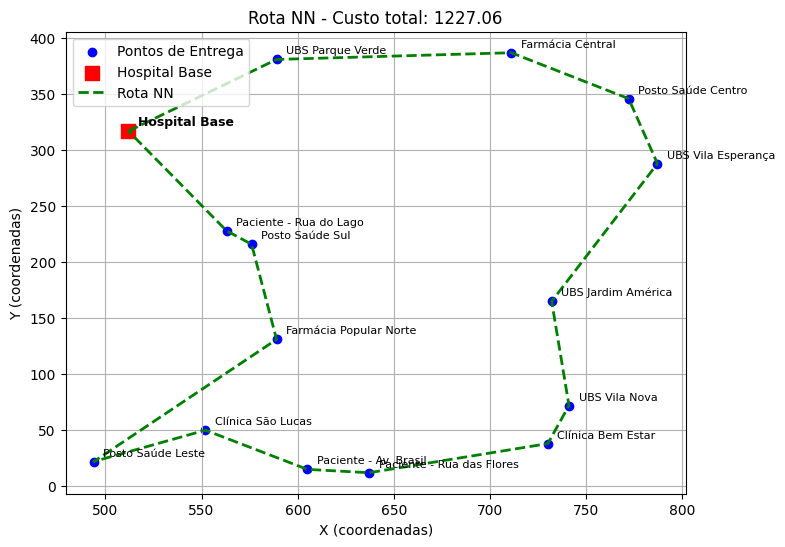

In [12]:
# ---------------------------------------------------------------------------
# Exemplo de uso da heurística Nearest Neighbor com o dataset de entregas
# ---------------------------------------------------------------------------

# Obter hospital base e pontos de entrega
hospital_base = get_hospital_base()
locais_entrega = get_pontos_entrega_sem_origem()

# Gerar rota baseline via NN
rota_nn, custo_nn = avaliar_baseline_nn(locais_entrega, hospital_base)

print("Rota NN (baseline):")
for p in rota_nn:
    print(f"- {p.nome} ({p.coords}) | prioridade={PRIORIDADE_LABEL.get(p.prioridade, 'Origem')}")

print(f"\nCusto total da rota NN: {custo_nn:.2f}")

# Gerar múltiplas soluções NN para inicializar população do GA
populacao_inicial = gerar_populacao_nearest_neighbor(locais_entrega, hospital_base, n_solucoes=5)

print("\nExemplos de rotas NN para população inicial:")
for i, rota in enumerate(populacao_inicial, start=1):
    nomes = " -> ".join([p.nome for p in rota])
    print(f"Solução {i}: {nomes}")

# ---------------------------------------------------------------------------
# Visualização gráfica da rota NN
# ---------------------------------------------------------------------------
# Obter hospital base e pontos de entrega
hospital_base = get_hospital_base()
locais_entrega = get_pontos_entrega_sem_origem()

# Calcular rota NN
rota_nn, custo_nn = avaliar_baseline_nn(locais_entrega, hospital_base)

# Preparar coordenadas
x_coords = [hospital_base.coords[0]] + [p.coords[0] for p in rota_nn] + [hospital_base.coords[0]]
y_coords = [hospital_base.coords[1]] + [p.coords[1] for p in rota_nn] + [hospital_base.coords[1]]

# Plotar pontos
plt.figure(figsize=(8,6))
plt.scatter([p.coords[0] for p in locais_entrega], 
            [p.coords[1] for p in locais_entrega], 
            c="blue", label="Pontos de Entrega")

plt.scatter(hospital_base.coords[0], hospital_base.coords[1], 
            c="red", marker="s", s=100, label="Hospital Base")

# Plotar rota NN
plt.plot(x_coords, y_coords, c="green", linestyle="--", linewidth=2, label="Rota NN")

# Anotar nomes dos pontos
for p in locais_entrega:
    plt.text(p.coords[0]+5, p.coords[1]+5, p.nome, fontsize=8)

plt.text(hospital_base.coords[0]+5, hospital_base.coords[1]+5, hospital_base.nome, fontsize=9, fontweight="bold")

plt.title(f"Rota NN - Custo total: {custo_nn:.2f}")
plt.xlabel("X (coordenadas)")
plt.ylabel("Y (coordenadas)")
plt.legend()
plt.grid(True)
plt.show()    


### Executando o gráfico comparativo das Rotas NN vs GA + Two Opt

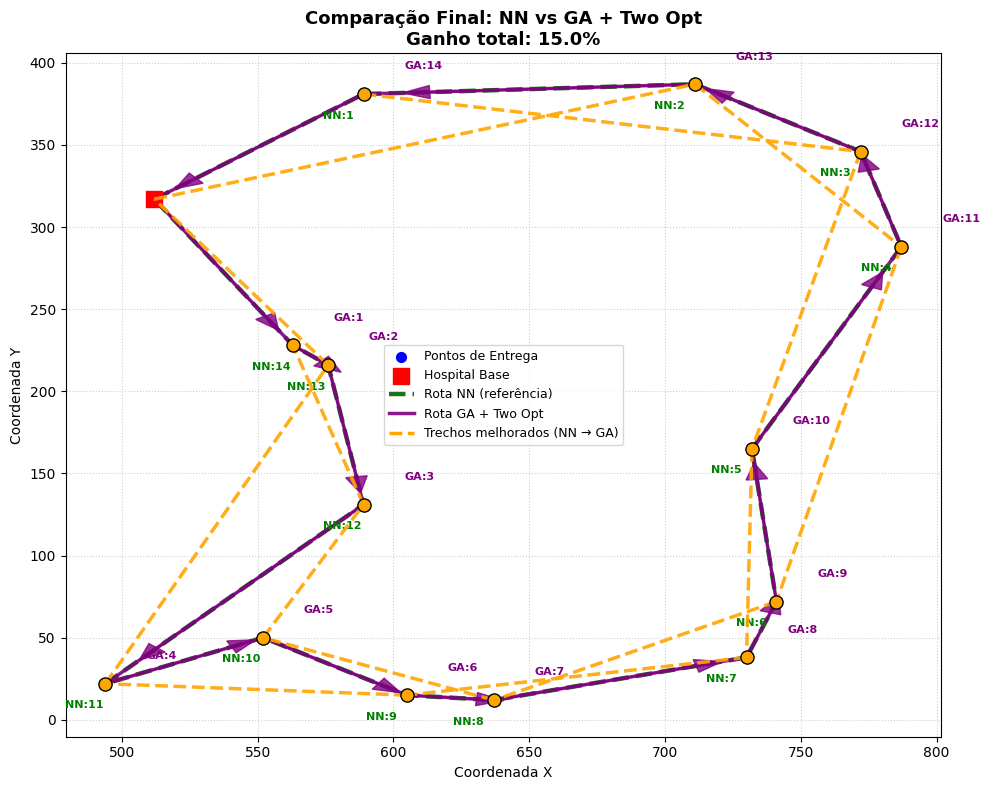

In [13]:
# ---------------------------------------------------------------------------
# Grafico de comparação NN vs GA + Two Opt com numeração dupla nos pontos
# ---------------------------------------------------------------------------
 

hospital_base = get_hospital_base()
locais_entrega = get_pontos_entrega_sem_origem()

rota_nn, custo_nn = avaliar_baseline_nn(locais_entrega, hospital_base)
# Substitua pela sua função real:
# rota_ga, custo_ga = executar_ga_two_opt(locais_entrega, hospital_base)
rota_ga, custo_ga = rota_nn[::-1], custo_nn * 0.85  # simulação invertendo ordem

def extrair_coords(rota):
    x = [hospital_base.coords[0]] + [p.coords[0] for p in rota] + [hospital_base.coords[0]]
    y = [hospital_base.coords[1]] + [p.coords[1] for p in rota] + [hospital_base.coords[1]]
    return np.array(x), np.array(y)

x_nn, y_nn = extrair_coords(rota_nn)
x_ga, y_ga = extrair_coords(rota_ga)

ganho_percentual = ((custo_nn - custo_ga) / custo_nn) * 100

fig, ax = plt.subplots(figsize=(10,8))

# Pontos e hospital
ax.scatter([p.coords[0] for p in locais_entrega],
           [p.coords[1] for p in locais_entrega],
           c="blue", s=50, label="Pontos de Entrega", zorder=3)
ax.scatter(hospital_base.coords[0], hospital_base.coords[1],
           c="red", marker="s", s=120, label="Hospital Base", zorder=4)

# Rota NN (referência verde tracejada com sombra)
ax.plot(x_nn, y_nn, c="darkgreen", linestyle="--", linewidth=3.2, alpha=0.9, zorder=1, label="Rota NN (referência)")
ax.plot(x_nn, y_nn, c="limegreen", linestyle="--", linewidth=1.5, alpha=0.6, zorder=0)  # sombra leve

# Rota GA + Two Opt (principal)
ax.plot(x_ga, y_ga, c="purple", linestyle="-", linewidth=2.5, alpha=0.9, zorder=2, label="Rota GA + Two Opt")
for i in range(len(x_ga)-1):
    dx, dy = x_ga[i+1] - x_ga[i], y_ga[i+1] - y_ga[i]
    ax.arrow(x_ga[i], y_ga[i], dx*0.8, dy*0.8, head_width=8, head_length=10,
             fc="purple", ec="purple", alpha=0.8, zorder=2)

# Destacar apenas os trechos melhorados
for p in locais_entrega:
    idx_nn = rota_nn.index(p)
    idx_ga = rota_ga.index(p)
    if idx_nn != idx_ga:
        ax.plot([x_nn[idx_nn], x_ga[idx_ga]], [y_nn[idx_nn], y_ga[idx_ga]],
                c="orange", linestyle="--", linewidth=2.5, alpha=0.9, zorder=5)
        ax.scatter(p.coords[0], p.coords[1], c="orange", s=90, edgecolors="black", zorder=6)

    # Numeração dupla em cada ponto
    ax.text(p.coords[0]-15, p.coords[1]-15, f"NN:{idx_nn+1}", color="green", fontsize=8, fontweight="bold")
    ax.text(p.coords[0]+15, p.coords[1]+15, f"GA:{idx_ga+1}", color="purple", fontsize=8, fontweight="bold")

# Legenda clara e completa
ax.plot([], [], c="orange", linestyle="--", linewidth=2.5, label="Trechos melhorados (NN → GA)")
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="best", fontsize=9, frameon=True)

ax.set_title(f"Comparação Final: NN vs GA + Two Opt\nGanho total: {ganho_percentual:.1f}%", fontsize=13, fontweight="bold")
ax.set_xlabel("Coordenada X")
ax.set_ylabel("Coordenada Y")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()




### Explicando Comparação das Rotas NN vs GA + Two Opt

Nesta visualização acima foi comparado duas abordagens de roteamento:

- **Rota NN (Nearest Neighbor)**:  
  Representada em **verde tracejado**, mostra a rota original obtida pelo algoritmo do vizinho mais próximo.  
  Essa rota serve como **referência** para entendermos o ponto de partida.

- **Rota GA + Two Opt**:  
  Representada em **roxo contínuo com setas**, mostra a rota otimizada pelo algoritmo genético combinado com a técnica Two Opt.  
  Essa rota reorganiza a ordem de visita dos pontos para reduzir o custo total.

- **Trechos melhorados (NN → GA)**:  
  Representados em **laranja tracejado**, destacam apenas os segmentos onde houve **mudança de ordem** ou **encurtamento**.  
  São os pontos em que o GA + Two Opt trouxe ganho real de eficiência.

- **Numeração dupla em cada ponto**:  
  Cada ponto de entrega mostra dois rótulos:  
  - `NN:x` → posição na rota NN  
  - `GA:y` → posição na rota GA + Two Opt  
  Isso evidencia que os pontos são os mesmos, mas a **sequência de visita** é diferente.

- **Hospital Base**:  
  Representado em **vermelho**, é o ponto de origem e retorno da rota.

- **Pontos de Entrega**:  
  Representados em **azul**, são os locais que precisam ser atendidos.

#### Interpretação
O gráfico mostra que, embora as rotas NN e GA passem pelos mesmos pontos e muitas vezes se sobreponham espacialmente, a **ordem de visita** é diferente.  
Essa reorganização elimina cruzamentos e reduz o custo total da rota, resultando em um **ganho percentual de eficiência** exibido no título do gráfico.


# Algoritimo Genético


Algoritmo Genético para Otimização de Rotas Médicas (TSP).

Nomenclatura alinhada ao domínio de negócio:
    - population     → populacao_rotas
    - individual     → rota
    - cities         → locais_entrega
    - fitness        → custo_rota

O hospital base (ponto de origem) é fixo: não entra na permutação.
Ele é adicionado implicitamente no início e no fim ao calcular o custo da rota,
garantindo que toda rota seja um ciclo fechado com origem e retorno ao hospital.

Função de custo (fitness):
    custo = distancia_total + penalidade_prioridade

    penalidade_prioridade: pacientes de alta prioridade atendidos tarde na rota
    recebem penalidade proporcional à sua posição × fator de prioridade.
    Prioridade 1 (Alta) penaliza mais do que prioridade 2 (Média).


In [ ]:




# ---------------------------------------------------------------------------
# Distância
# ---------------------------------------------------------------------------

def calcular_distancia(p1: PontoEntrega, p2: PontoEntrega) -> float:
    """Calcula a distância Euclidiana entre dois pontos de entrega."""
    return math.sqrt((p1.coords[0] - p2.coords[0]) ** 2 +
                     (p1.coords[1] - p2.coords[1]) ** 2)

def calcular_distancia_rota(
    rota: List[PontoEntrega],
    hospital_base: PontoEntrega,
) -> float:
    """
    Calcula somente a distância Euclidiana total do ciclo fechado (sem penalidades).

    Útil para verificar restrição de autonomia separadamente do custo fitness.

    Parâmetros:
    - rota: sequência de pontos de entrega (sem o hospital base)
    - hospital_base: ponto de origem e retorno

    Retorno:
    - distância total do ciclo em pixels
    """
    rota_completa = [hospital_base] + list(rota) + [hospital_base]
    return sum(
        calcular_distancia(rota_completa[i], rota_completa[i + 1])
        for i in range(len(rota_completa) - 1)
    )

# ---------------------------------------------------------------------------
# Função de custo (fitness)
# ---------------------------------------------------------------------------

def calcular_custo_rota(
    rota: List[PontoEntrega],
    hospital_base: PontoEntrega,
    fator_penalidade: float = FATOR_PENALIDADE_PRIORIDADE,
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    fator_penalidade_capacidade: float = FATOR_PENALIDADE_CAPACIDADE,
    fator_penalidade_autonomia: float = FATOR_PENALIDADE_AUTONOMIA,
) -> float:
    """
    Calcula o custo total de uma rota incluindo distância e penalidades de restrições.

    Penalidades aplicadas:
    - Prioridade   : pacientes críticos atendidos tarde recebem penalidade proporcional
                     à (posição / prioridade) × fator_penalidade.
    - Capacidade   : excesso de carga além de ``capacidade_veiculo`` é penalizado de forma
                     proporcional ao excesso relativo (excesso/capacidade × fator).
    - Autonomia    : excesso de distância além de ``autonomia_veiculo`` é penalizado por
                     (excesso_pixels × fator_penalidade_autonomia).
    """
    rota_completa = [hospital_base] + list(rota) + [hospital_base]
    n = len(rota_completa)

    # Distância total do ciclo
    distancia_total = sum(
        calcular_distancia(rota_completa[i], rota_completa[i + 1])
        for i in range(n - 1)
    )

    # Penalidade por prioridade
    penalidade_prioridade = 0.0
    for posicao, ponto in enumerate(rota, start=1):
        if ponto.prioridade in (1, 2):
            penalidade_prioridade += (posicao / ponto.prioridade) * fator_penalidade

    # Penalidade proporcional por capacidade
    penalidade_capacidade = 0.0
    if capacidade_veiculo is not None:
        peso_total = sum(p.peso for p in rota)
        excesso = max(0.0, peso_total - capacidade_veiculo)
        if excesso > 0:
            excesso_relativo = excesso / capacidade_veiculo
            penalidade_capacidade = excesso_relativo * fator_penalidade_capacidade

    # Penalidade por autonomia
    penalidade_autonomia = 0.0
    if autonomia_veiculo is not None:
        excesso = max(0.0, distancia_total - autonomia_veiculo)
        penalidade_autonomia = excesso * fator_penalidade_autonomia

    return distancia_total + penalidade_prioridade + penalidade_capacidade + penalidade_autonomia

def calcular_custo_giant_tour_vrp(
    giant_tour: List[PontoEntrega],
    hospital_base: PontoEntrega,
    n_veiculos: int,
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    fator_penalidade: float = FATOR_PENALIDADE_PRIORIDADE,
    fator_penalidade_capacidade: float = FATOR_PENALIDADE_CAPACIDADE,
    fator_penalidade_autonomia: float = FATOR_PENALIDADE_AUTONOMIA,
) -> float:
    rotas: List[List[PontoEntrega]] = []
    rota_atual: List[PontoEntrega] = []
    peso_atual: float = 0.0
    dist_atual: float = 0.0
    ponto_anterior: PontoEntrega = hospital_base

    for ponto in giant_tour:
        dist_passo = calcular_distancia(ponto_anterior, ponto)
        dist_retorno = calcular_distancia(ponto, hospital_base)

        capacidade_violada = (
            capacidade_veiculo is not None
            and peso_atual + ponto.peso > capacidade_veiculo
        )
        autonomia_violada = (
            autonomia_veiculo is not None
            and dist_atual + dist_passo + dist_retorno > autonomia_veiculo
        )

        veiculos_disponiveis = len(rotas) < n_veiculos - 1
        if (capacidade_violada or autonomia_violada) and rota_atual and veiculos_disponiveis:
            rotas.append(rota_atual)
            rota_atual = []
            peso_atual = 0.0
            dist_atual = 0.0
            ponto_anterior = hospital_base
            dist_passo = calcular_distancia(hospital_base, ponto)

        rota_atual.append(ponto)
        peso_atual += ponto.peso
        dist_atual += dist_passo
        ponto_anterior = ponto

    if rota_atual:
        rotas.append(rota_atual)

    # Soma dos custos de cada sub-rota com refinamento Two-Opt
    custo_total = 0.0
    for rota in rotas:
        rota_otimizada, _ = two_opt_inversion(rota, hospital_base)
        custo_total += calcular_custo_rota(
            rota_otimizada, hospital_base,
            fator_penalidade=fator_penalidade,
            capacidade_veiculo=capacidade_veiculo,
            autonomia_veiculo=autonomia_veiculo,
            fator_penalidade_capacidade=fator_penalidade_capacidade,
            fator_penalidade_autonomia=fator_penalidade_autonomia,
        )
    return custo_total


# ---------------------------------------------------------------------------
# Geração de população inicial
# ---------------------------------------------------------------------------

def gerar_populacao_aleatoria(
    locais_entrega: List[PontoEntrega],
    tamanho_populacao: int
) -> List[List[PontoEntrega]]:
    """
    Gera uma população de rotas aleatórias por permutação dos locais de entrega.

    O hospital base NÃO é incluído nas rotas — ele é tratado como origem fixa.

    Parâmetros:
    - locais_entrega: pontos de entrega (sem o hospital base)
    - tamanho_populacao: número de rotas a gerar

    Retorno:
    - lista de rotas (cada rota é uma permutação dos locais_entrega)
    """
    return [random.sample(locais_entrega, len(locais_entrega))
            for _ in range(tamanho_populacao)]

# ---------------------------------------------------------------------------
# Ordenação da população
# ---------------------------------------------------------------------------

def ordenar_populacao(
    populacao_rotas: List[List[PontoEntrega]],
    custos: List[float]
) -> Tuple[List[List[PontoEntrega]], List[float]]:
    """
    Ordena a população de rotas do menor custo (melhor) para o maior (pior).

    Parâmetros:
    - populacao_rotas: lista de rotas
    - custos: lista de custos correspondentes a cada rota

    Retorno:
    - tupla (populacao_ordenada, custos_ordenados)
    """
    combinado = sorted(zip(populacao_rotas, custos), key=lambda x: x[1])
    populacao_ordenada, custos_ordenados = zip(*combinado)
    return list(populacao_ordenada), list(custos_ordenados)



In [ ]:
# ---------------------------------------------------------------------------
# Loop evolutivo principal
# ---------------------------------------------------------------------------
def executar_algoritmo_genetico(
    locais_entrega: List[PontoEntrega],
    hospital_base: PontoEntrega,
    populacao_inicial: List[List[PontoEntrega]],
    n_geracoes: int = 1000,
    probabilidade_mutacao: float = 0.5,
    probabilidade_crossover: float = 1.0,
    n_veiculos: int = 1,
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    verbose: bool = True
) -> Tuple[List[PontoEntrega], float, List[float], List[float], List[Tuple[int, str]]]:

    populacao_rotas = populacao_inicial
    melhor_rota: Optional[List[PontoEntrega]] = None
    melhor_custo: float = float("inf")
    historico_custos: List[float] = []
    historico_media: List[float] = []

    geracoes_sem_melhora = 0
    taxa_mutacao_atual = probabilidade_mutacao

    # Initialize eventos here
    eventos: List[Tuple[int, str]] = []

    for geracao in range(1, n_geracoes + 1):
        # Avaliar custos da população
        if n_veiculos == 1:
            custos = [
                calcular_custo_rota(
                    rota,
                    hospital_base,
                    capacidade_veiculo=capacidade_veiculo,
                    autonomia_veiculo=autonomia_veiculo
                )
                for rota in populacao_rotas
            ]
        else:
            custos = []
            for rota in populacao_rotas:
                # refinamento Two-Opt em cada sub-rota do VRP Split
               custo_total = calcular_custo_giant_tour_vrp(
                    rota,
                    hospital_base,
                    n_veiculos=n_veiculos,
                    capacidade_veiculo=capacidade_veiculo,
                    autonomia_veiculo=autonomia_veiculo
                )

               custos.append(custo_total)

        media_custo = np.mean(custos)
        historico_media.append(media_custo)

        # elitismo
        idx_melhor = np.argmin(custos)
        if custos[idx_melhor] < melhor_custo:
            melhor_rota = populacao_rotas[idx_melhor]
            melhor_custo = custos[idx_melhor]
            geracoes_sem_melhora = 0
        else:
            geracoes_sem_melhora += 1

        historico_custos.append(melhor_custo)

        if verbose:
            print(f"Geração {geracao:4d}: melhor custo = {melhor_custo:.2f} (sem melhoria: {geracoes_sem_melhora}/150)")

        # Moved events initialization outside the loop
        eventos = []

        # Repopulação adaptativa
        frac_replace = 0.25

        if geracoes_sem_melhora >= PACIENCIA_ESPERA:
            populacao_rotas = repopular_adaptativa(populacao_rotas, locais_entrega, hospital_base, frac_replace=frac_replace)
            eventos.append((geracao, "Repopulação"))
            geracoes_sem_melhora = 0
            if verbose:
                print(f"🔁 Repopulação adaptativa aplicada na geração {geracao}")

        # ''' if geracoes_sem_melhora > 15:
        #     taxa_mutacao_atual = min(1.0, probabilidade_mutacao * 2.0)
        #     if verbose:
        #         print(f"⚡ Mutação adaptativa ativada na geração {geracao}: taxa = {taxa_mutacao_atual:.2f}")
        # '''
        nova_populacao = [melhor_rota]  # elitismo

        # gerar filhos
        while len(nova_populacao) < len(populacao_rotas):
            pai1, pai2 = random.sample(populacao_rotas, 2)

            # crossover variado
            if random.random() < 0.33:
                filho1, filho2 = order_crossover(pai1, pai2)
            elif random.random() < 0.66:
                filho1, filho2 = pmx_crossover(pai1, pai2)
            else:
                filho1, filho2 = (
                    mutate_segment_inversion(pai1, taxa_mutacao_atual),
                    mutate_segment_inversion(pai2, taxa_mutacao_atual)
                )

            # mutação para filho1
            if random.random() < taxa_mutacao_atual:
                r_mutate = random.random()
                if r_mutate < 0.33:
                    filho1 = mutate_swap(filho1)
                elif r_mutate < 0.66:
                    filho1 = mutate_insertion(filho1)
                else:
                    filho1 = mutate_segment_inversion(filho1, taxa_mutacao_atual)

            # mutação para filho2
            if random.random() < taxa_mutacao_atual:
                r_mutate = random.random()
                if r_mutate < 0.33:
                    filho2 = mutate_swap(filho2)
                elif r_mutate < 0.66:
                    filho2 = mutate_insertion(filho2)
                else:
                    filho2 = mutate_segment_inversion(filho2, taxa_mutacao_atual)

            # refinamento Two-Opt nos filhos
            filho1, _ = two_opt_inversion(filho1, hospital_base)
            filho2, _ = two_opt_inversion(filho2, hospital_base)

            nova_populacao.extend([filho1, filho2])

        populacao_rotas = nova_populacao[:len(populacao_rotas)]

        # aplicar Two-Opt periodicamente na melhor rota
        if geracao % 10 == 0 and melhor_rota is not None:
            rota_otimizada, custo_otimizado = two_opt_inversion(melhor_rota, hospital_base)
            if custo_otimizado < melhor_custo:
                melhor_rota, melhor_custo = rota_otimizada, custo_otimizado
                eventos.append((geracao, f"Two-Opt melhorou (custo={melhor_custo:.2f})"))
                if verbose:
                    print(f"✨ Two-Opt melhorou na geração {geracao}: custo = {melhor_custo:.2f}")

    return melhor_rota, melhor_custo, historico_custos, historico_media, eventos

# Two Opt

Heurística de Melhoria: Two Opt Inversion para TSP.

Algoritmo:
    Para cada par de arestas (i, k) na rota:
        - Inverte o segmento entre os índices i+1 e k (inclusive).
        - Se o novo custo for menor, aceita a melhoria.
        - Repete até não encontrar mais melhorias (convergência local).

Aplica o Two Opt Inversion sobre uma rota para refinamento local.

    Para cada par de arestas (i, k), testa se inverter o segmento [i+1 .. k]
    reduz o custo total. Aceita imediatamente a primeira melhoria encontrada
    (estratégia first improvement) e reinicia a busca.

    Parâmetros:
    - rota: sequência de pontos de entrega (sem o hospital base nos extremos)
    - hospital_base: ponto de origem e retorno (usado no cálculo do custo)
    - max_iteracoes: limite máximo de iterações para evitar loop infinito
    - verbose: se True, imprime cada melhoria encontrada

    Retorno:
    - (rota_otimizada, custo_otimizado)        

Complexidade por iteração: O(n²)
Uso no pipeline:
    - Aplicado UMA VEZ sobre a melhor rota encontrada pelo GA após convergência.
    - Refinamento local que elimina cruzamentos de arestas e reduz custo final.
    - Não modifica o GA — é uma etapa de pós-processamento.
    

In [ ]:
from typing import List, Tuple

def two_opt_inversion(
    rota: List[PontoEntrega],
    hospital_base: PontoEntrega,
    max_iteracoes: int = 1000,
    verbose: bool = False
) -> Tuple[List[PontoEntrega], float]:
    melhor_rota = list(rota)
    melhor_custo = calcular_custo_rota(melhor_rota, hospital_base)
    n = len(melhor_rota)
    iteracao = 0
    melhoria_encontrada = True

    while melhoria_encontrada and iteracao < max_iteracoes:
        melhoria_encontrada = False
        iteracao += 1

        for i in range(n - 1):
            for k in range(i + 1, n):
                # Gera nova rota invertendo o segmento entre i+1 e k
                nova_rota = melhor_rota[:i + 1] + \
                            melhor_rota[i + 1:k + 1][::-1] + \
                            melhor_rota[k + 1:]

                novo_custo = calcular_custo_rota(nova_rota, hospital_base)

                if novo_custo < melhor_custo:
                    melhor_rota = nova_rota
                    melhor_custo = novo_custo
                    melhoria_encontrada = True

                    if verbose:
                        print(f"  Two Opt iter {iteracao}: inversão [{i+1}:{k+1}] "
                              f"→ custo = {melhor_custo:.2f}")
                    break  # first improvement: reinicia

            if melhoria_encontrada:
                break

    return melhor_rota, melhor_custo


# VRP Split

VRP Split: particionamento de giant tour em sub-rotas por veículo.

Abordagem "Penalized GA + Greedy Split":
    1. O GA otimiza um "giant tour" (permutação de todos os pontos) com
       penalidades por violação de capacidade e autonomia, resultando numa
       ordenação de pontos que minimiza o custo total considerando as restrições.
    2. Este módulo particiona o giant tour em sub-rotas válidas para cada
       veículo usando o algoritmo de particionamento guloso (greedy split):
       - Adiciona pontos à rota do veículo atual enquanto as restrições forem
         respeitadas.
       - Quando adicionar o próximo ponto violaria capacidade ou autonomia,
         fecha a rota do veículo atual e inicia uma nova rota.

Complexidade: O(n) — percorre o giant tour uma única vez.

    Divide um giant tour em sub-rotas válidas para múltiplos veículos.

    Utiliza particionamento guloso: percorre o giant tour sequencialmente e
    abre uma nova rota de veículo sempre que adicionar o próximo ponto violaria
    a capacidade ou a autonomia do veículo atual.

    Parâmetros:
    - giant_tour: permutação completa de todos os pontos de entrega
    - hospital_base: ponto de origem e retorno (depósito)
    - capacidade_veiculo: carga máxima por veículo em unidades (None = irrestrito)
    - autonomia_veiculo: distância máxima por ciclo em pixels (None = irrestrito)
    - n_veiculos: número máximo de veículos disponíveis (None = irrestrito).
                  Se as restrições exigirem mais veículos do que este limite,
                  o excedente é adicionado ao último veículo (infeasível, mas
                  mantém todos os pontos cobertos).

    Retorno:
    - lista de sub-rotas, uma por veículo; cada sub-rota é uma lista de
      pontos de entrega (sem o hospital base nos extremos).

Referências:
    - Prins, C. (2004). A simple and effective evolutionary algorithm for the
      vehicle routing problem. Computers & Operations Research, 31(12).
      

In [ ]:
from typing import List, Optional, Tuple

def dividir_rotas_vrp(
    giant_tour: List[PontoEntrega],
    hospital_base: PontoEntrega,
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
    n_veiculos: Optional[int] = None,
) -> List[List[PontoEntrega]]:
    """

    """
    rotas: List[List[PontoEntrega]] = []
    rota_atual: List[PontoEntrega] = []
    peso_atual: float = 0.0
    dist_atual: float = 0.0
    ponto_anterior: PontoEntrega = hospital_base

    for ponto in giant_tour:
        dist_passo = calcular_distancia(ponto_anterior, ponto)
        dist_retorno = calcular_distancia(ponto, hospital_base)

        capacidade_violada = (
            capacidade_veiculo is not None
            and peso_atual + ponto.peso > capacidade_veiculo
        )
        autonomia_violada = (
            autonomia_veiculo is not None
            and dist_atual + dist_passo + dist_retorno > autonomia_veiculo
        )

        # Se há violação E a rota atual já tem pelo menos um ponto,
        # e ainda há veículos disponíveis → fecha a rota e abre nova.
        # O limite é `n_veiculos - 1` porque o último veículo é reservado
        # para absorver todos os pontos restantes (incluindo os infeasíveis):
        # len(rotas) < n_veiculos - 1  →  "posso abrir mais um veículo"
        # len(rotas) == n_veiculos - 1 →  "já tenho n_veiculos-1 rotas fechadas;
        #                                   o veículo atual É o último disponível"
        veiculos_disponiveis = n_veiculos is None or len(rotas) < n_veiculos - 1
        if (capacidade_violada or autonomia_violada) and rota_atual and veiculos_disponiveis:
            rotas.append(rota_atual)
            rota_atual = []
            peso_atual = 0.0
            dist_atual = 0.0
            ponto_anterior = hospital_base
            # Recalcula distância do depósito até este ponto
            dist_passo = calcular_distancia(hospital_base, ponto)

        rota_atual.append(ponto)
        peso_atual += ponto.peso
        dist_atual += dist_passo
        ponto_anterior = ponto

    if rota_atual:
        rotas.append(rota_atual)

    return rotas


def calcular_custo_vrp(
    rotas_vrp: List[List[PontoEntrega]],
    hospital_base: PontoEntrega,
    capacidade_veiculo: Optional[float] = None,
    autonomia_veiculo: Optional[float] = None,
) -> Tuple[float, List[float]]:
    """
    Calcula o custo total da solução VRP e o custo individual de cada veículo.

    Parâmetros:
    - rotas_vrp: lista de sub-rotas (uma por veículo)
    - hospital_base: ponto de origem e retorno
    - capacidade_veiculo: limite de carga por veículo (None = irrestrito)
    - autonomia_veiculo: limite de distância por veículo (None = irrestrito)

    Retorno:
    - (custo_total, custos_por_veiculo)
    """
    custos = [
        calcular_custo_rota(
            rota, hospital_base,
            capacidade_veiculo=capacidade_veiculo,
            autonomia_veiculo=autonomia_veiculo,
        )
        for rota in rotas_vrp
    ]
    return sum(custos), custos


def resumo_restricoes_vrp(
    rotas_vrp: List[List[PontoEntrega]],
    hospital_base: PontoEntrega,
    capacidade_veiculo: Optional[float],
    autonomia_veiculo: Optional[float],
) -> List[dict]:
    """
    Gera um resumo das métricas de restrição por veículo.

    Retorno:
    - lista de dicionários com métricas de cada veículo
    """
    resumo = []
    for idx, rota in enumerate(rotas_vrp, start=1):
        peso = sum(p.peso for p in rota)
        rota_completa = [hospital_base] + rota + [hospital_base]
        distancia = sum(
            calcular_distancia(rota_completa[i], rota_completa[i + 1])
            for i in range(len(rota_completa) - 1)
        )
        capacidade_ok = capacidade_veiculo is None or peso <= capacidade_veiculo
        autonomia_ok = autonomia_veiculo is None or distancia <= autonomia_veiculo

        resumo.append({
            "veiculo": idx,
            "n_pontos": len(rota),
            "peso_total": round(peso, 2),
            "capacidade_veiculo": capacidade_veiculo,
            "capacidade_ok": capacidade_ok,
            "distancia_pixels": round(distancia, 2),
            "autonomia_veiculo": autonomia_veiculo,
            "autonomia_ok": autonomia_ok,
            "pontos": [p.nome for p in rota],
        })
    return resumo


# População inicial (NN + aleatória)

In [ ]:
pop_random = gerar_populacao_aleatoria(locais_entrega, tamanho_populacao=80)
pop_nn = gerar_populacao_nearest_neighbor(locais_entrega, hospital_base, n_solucoes=20)

pop_inicial = pop_random + pop_nn


# População

In [ ]:
# --- Repopulação adaptativa ---
def repopular_adaptativa(populacao, locais_entrega, hospital_base, frac_replace=0.25, seed=None):
    """Substitui parte da população por novas soluções aleatórias."""
    if seed is not None:
        random.seed(seed)
    n = len(populacao)
    n_replace = max(1, int(n * frac_replace))
    indices = random.sample(range(n), n_replace)
    novas = gerar_populacao_aleatoria(locais_entrega, tamanho_populacao=n_replace)
    for idx, novo in zip(indices, novas):
        populacao.copy()[idx] = novo
    return populacao.copy()

# Executar GA

Rotina que faz a execução do algoritimo genético

In [ ]:

melhor_rota, melhor_custo, historico_custos, historico_media, eventos = executar_algoritmo_genetico(
    locais_entrega,
    hospital_base,
    populacao_inicial=pop_inicial,
    n_geracoes=200,
    probabilidade_mutacao=0.5,
    probabilidade_crossover=1.0,
    n_veiculos=2,              # exemplo com 2 veículos
    capacidade_veiculo=6.0,    # capacidade máxima
    autonomia_veiculo=20.0,    # autonomia máxima
    verbose=True
)

print("Melhor rota encontrada:", melhor_rota)
print("Custo total:", melhor_custo)


## Demonstração de Parametrizações do Algoritmo Genético

Vamos explorar como diferentes configurações de parâmetros afetam o desempenho do algoritmo genético. Abaixo, executaremos o GA com três conjuntos distintos de parâmetros.

### Configuração 1: Cenário Base (Gerações e Veículos Padrão)

In [ ]:
# Configuração 1: Cenário Base
print("\n--- Executando GA com Configuração 1 ---")
melhor_rota_cfg1, custo_cfg1, _, _ = executar_algoritmo_genetico(
    locais_entrega,
    hospital_base,
    populacao_inicial=pop_inicial,
    n_geracoes=100,  # Metade das gerações originais
    probabilidade_mutacao=0.5,
    probabilidade_crossover=1.0,
    n_veiculos=2,
    capacidade_veiculo=6.0,
    autonomia_veiculo=20.0,
    verbose=False # Desabilitar verbose para melhor visualização na demonstração
)
print("Configuração 1 - Melhor rota encontrada:", melhor_rota_cfg1)
print("Configuração 1 - Custo total:", custo_cfg1)

### Configuração 2: Mais Veículos, Restrições Mais Apertadas

In [ ]:
# Configuração 2: Mais Veículos, Restrições Mais Apertadas
print("\n--- Executando GA com Configuração 2 ---")
melhor_rota_cfg2, custo_cfg2, _, _ = executar_algoritmo_genetico(
    locais_entrega,
    hospital_base,
    populacao_inicial=pop_inicial,
    n_geracoes=150, # Mais gerações
    probabilidade_mutacao=0.6,
    probabilidade_crossover=1.0,
    n_veiculos=3,  # Mais veículos
    capacidade_veiculo=4.0, # Capacidade mais apertada
    autonomia_veiculo=15.0, # Autonomia mais apertada
    verbose=False
)
print("Configuração 2 - Melhor rota encontrada:", melhor_rota_cfg2)
print("Configuração 2 - Custo total:", custo_cfg2)

### Configuração 3: Cenário TSP (Um Veículo, Sem Restrições de Capacidade/Autonomia)

In [ ]:
# Configuração 3: Cenário TSP (Um Veículo, Sem Restrições)
print("\n--- Executando GA com Configuração 3 ---")
melhor_rota_cfg3, custo_cfg3, _, _ = executar_algoritmo_genetico(
    locais_entrega,
    hospital_base,
    populacao_inicial=pop_inicial,
    n_geracoes=50, # Menos gerações
    probabilidade_mutacao=0.4,
    probabilidade_crossover=1.0,
    n_veiculos=1,  # Apenas um veículo (TSP)
    capacidade_veiculo=None, # Sem restrição de capacidade
    autonomia_veiculo=None,  # Sem restrição de autonomia
    verbose=False
)
print("Configuração 3 - Melhor rota encontrada:", melhor_rota_cfg3)
print("Configuração 3 - Custo total:", custo_cfg3)

# Plot com eventos

In [ ]:
# --- Plot com eventos ---
def plot_evolucao_com_eventos(historico_melhor, historico_media=None, eventos=None, title="Evolução do custo"):
    gens = list(range(1, len(historico_melhor)+1))
    plt.figure(figsize=(10,5))
    plt.plot(gens, historico_melhor, label="Melhor custo", color="tab:blue")
    if historico_media is not None:
        plt.plot(gens, historico_media, label="Custo médio da população", color="tab:orange", linestyle="--")
    if eventos:
        for (g, label) in eventos:
            plt.axvline(g, color="red", linestyle=":", alpha=0.6)
            plt.text(g+0.5, max(historico_melhor)*0.98, label, rotation=90, color="red", fontsize=8, va="top")
    plt.xlabel("Geração")
    plt.ylabel("Custo da rota")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Refinamento com Two-Opt

In [ ]:
rota_otimizada, custo_otimizado = two_opt_inversion(melhor_rota, hospital_base, verbose=True)
print("Rota após Two-Opt:", rota_otimizada)
print("Custo otimizado:", custo_otimizado)

# Divisão em múltiplos veículos (VRP Split)

In [ ]:
rotas_vrp = dividir_rotas_vrp(rota_otimizada, hospital_base,
                              capacidade_veiculo=6.0,
                              autonomia_veiculo=20.0,
                              n_veiculos=2)

resumo = resumo_restricoes_vrp(rotas_vrp, hospital_base, capacidade_veiculo=6.0, autonomia_veiculo=20.0)
for r in resumo:
    print(r)


# Visualização

In [ ]:
coords = [hospital_base.coords] + [p.coords for p in rota_otimizada] + [hospital_base.coords]
x, y = zip(*coords)

plt.figure(figsize=(6,6))
plt.plot(x, y, marker="o")
for p in [hospital_base] + rota_otimizada:
    plt.text(p.coords[0]+0.1, p.coords[1]+0.1, p.nome)
plt.title("Rota Otimizada")
plt.show()


# Configuração da chave da API do Groq para uso no LLM

No Colab, use input() para digitar a chave manualmente

In [ ]:
from getpass import getpass

api_key = getpass("Digite sua chave Groq: ")
print("Chave recebida com sucesso!")  # só para confirmar, não imprime a chave


# Relatório com Groq

In [ ]:
from groq import Groq
client = Groq(api_key=api_key)

def gerar_relatorio(rotas, custo):
    prompt = f"""
    Você é um assistente logístico hospitalar. Explique em linguagem natural:
    - Rotas otimizadas: {rotas}
    - Custo total: {custo:.2f}
    Gere instruções claras para motoristas e um resumo da eficiência.
    """
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role":"user","content":prompt}],
        temperature=0.7
    )
    return response.choices[0].message.content

print(gerar_relatorio(rota_otimizada, custo_otimizado))


# Gráfico da evolução

Linha azul (melhor custo): cai de 72.17 para 68.10 na geração 10 e depois congela.

Linha laranja (média): mostra a evolução da população.

Linha vermelha tracejada: marca visualmente a geração 10.

Seta e anotação: destacam o momento da melhoria pelo Two-Opt.

In [ ]:
import matplotlib.pyplot as plt

geracoes = range(1, len(historico_custos) + 1)

plt.figure(figsize=(12,6))
plt.plot(geracoes, historico_custos, label="Melhor custo", color="blue", linewidth=2)
plt.plot(geracoes, historico_media, label="Custo médio da população", color="orange", linestyle="--")

# Linha vertical tracejada na geração 10
plt.axvline(x=10, color="red", linestyle="--", linewidth=1.5, label="Two-Opt (Geração 10)")

# Anotação na geração 10
plt.scatter(10, historico_custos[9], color="red", s=80, zorder=5)
plt.annotate(
    "Two-Opt melhorou aqui",
    xy=(10, historico_custos[9]),
    xytext=(30, historico_custos[9] + 2),
    arrowprops=dict(facecolor="red", shrink=0.05, width=2),
    fontsize=12,
    color="red"
)

plt.title("Evolução do custo no Algoritmo Genético")
plt.xlabel("Geração")
plt.ylabel("Custo da rota")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
plot_evolucao_com_eventos(historico_custos, historico_media, eventos)